# Homework2

##Q1

(a)

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [101]:
def normalized_histogram(img):
  hist=np.zeros(256)

  for i in range(len(img)):
    for j in range(len(img[0])):
      hist[img[i][j]]+=1

  hist=hist/np.sum(hist)

  return hist

def KL_divergence(px,py):
  KL=0
  for i in range(len(px)):
    if(py[i]==0 or px[i]==0):
      continue
    KL=KL+px[i]*np.log2(px[i]/py[i])
  return KL

def entropy(px):
  Entropy=0
  for i in range(len(px)):
    if(px[i]==0):
      continue
    Entropy=Entropy-px[i]*np.log2(px[i])

  return Entropy

In [102]:
from google.colab import drive
drive.mount('/content/drive')

image_path = "/content/drive/MyDrive/left.png"
left = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

image_path = "/content/drive/MyDrive/right.png"
right = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(i)

In [103]:
def cross_entropy(px,py):

  en=entropy(px)
  kl=KL_divergence(px,py)

  ce=en+kl

  return ce

px=normalized_histogram(left)
py=normalized_histogram(right)

print("Cross entropy is :",cross_entropy(px,py))

Cross entropy is : 7.273398119987328


(ii)

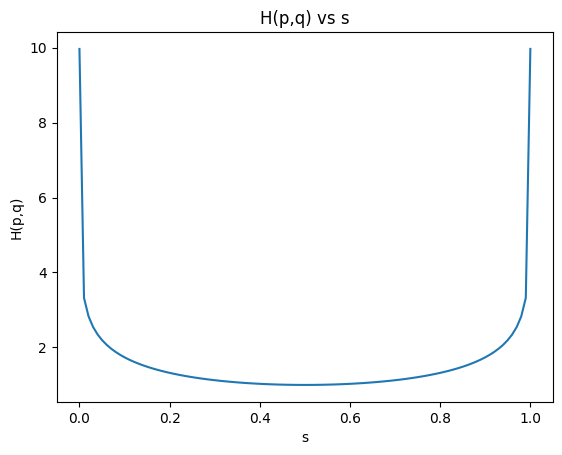

In [104]:
r=0.5
px=[r,1-r]

e=0.000001
s=np.linspace(0+e,1-e,100)

b=[]
for i in range(len(s)):
  py=[s[i],1-s[i]]
  ce=cross_entropy(px,py)
  b.append(ce)

#print(b)
plt.plot(s,b)
plt.title("H(p,q) vs s")
plt.xlabel("s")
plt.ylabel("H(p,q)")
plt.show()

from graph H(p,q) vs s ,H(p,q) attain minimun value at s=0.5,
when s=0.5,py=[0.5,0.5]

Therefore minimizing H(p,q) give same pdf px,py

(b)

In [116]:
def js(px,py):
  m=(np.array(px)+np.array(py))/2

  js=0.5*KL_divergence(px,m)+0.5*KL_divergence(py,m)

  return js

px=normalized_histogram(left)
py=normalized_histogram(right)

print("Jensen Shannon Divergence of left and right image is :",js(px,py))
print("Jensen Shannon Divergence of right and left image is :",js(py,px))

print("KL divergence of left and right is :",KL_divergence(px,py))
print("KL divergence of right and left is :",KL_divergence(py,px))

Jensen Shannon Divergence of left and right image is : 0.0036730397693148257
Jensen Shannon Divergence of right and left image is : 0.0036730397693148257
KL divergence of left and right is : 0.015104015237387055
KL divergence of right and left is : 0.014409785833354494


Jensen Shannon Divergence is symmetric but KL divergence is not symmetric.

(c)

In [117]:
def checkjointpdf(joint_histogram, marginal_X, marginal_Y):

    Mx = np.sum(joint_histogram, axis=1)
    My = np.sum(joint_histogram, axis=0)


    for i in range(len(Mx)):
      if(abs(Mx[i]-marginal_X[i])<1e-5):
        continue
      else:
        return False

    for i in range(len(My)):
      if(abs(My[i]-marginal_Y[i])<1e-5):
        continue
      else:
        return False

    return True

# Positive example
joint_histogram_pos = np.array([
    [0.1, 0.2, 0.3],
    [0.2, 0.1, 0.1]
])
marginal_X = np.array([0.6, 0.4])
marginal_Y = np.array([0.3, 0.3, 0.4])

print("Positive example result:", checkjointpdf(joint_histogram_pos, marginal_X, marginal_Y))

# Negative example
joint_histogram_neg = np.array([
    [0.1, 0.2, 0.2],
    [0.2, 0.1, 0.2]
])
marginal_X = np.array([0.5, 0.5])
marginal_Y = np.array([0.3, 0.4, 0.3])

print("Negative example result:", checkjointpdf(joint_histogram_neg, marginal_X, marginal_Y))


Positive example result: True
Negative example result: False


# Q2

(a)

(i)
The crowding problem occur when data of high dimensional space concentrate at same location in lower dimensional space.Points that are far apart in high high-dimensional space get forced too close together in lower-dimensional space.This occurs because lower dimensional dont have enough area to represent all pairwise distances from high dimenional space.This often results in a crowded representation where points are too close together and fail to reflect the true relationships between them.

(ii)
The Student t-distribution with low degrees of freedom is used in the low-dimensional embedding space of t-SNE. t-distribution has heavier tails which make it easy to maintain the relative distances between points in low dimensional space that are farther apart in the high-dimensional space. As a result,Student t-distribution in the low dimensional embedding space able to get rid of the crowding problem.

(iii)
In tsne we use Student t-distribution and in sne we use gaussian distribution,which helps to get rid of the crowding problem and better preserve the structure of the datat. t-SNE also introduces the concept of perplexity and uses more advanced optimization techniques, making it more effective.

(b)

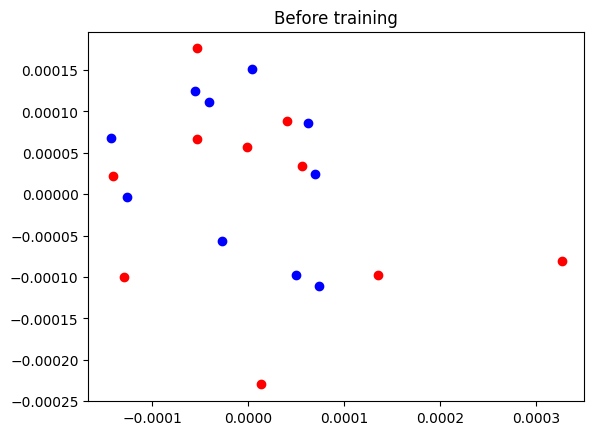

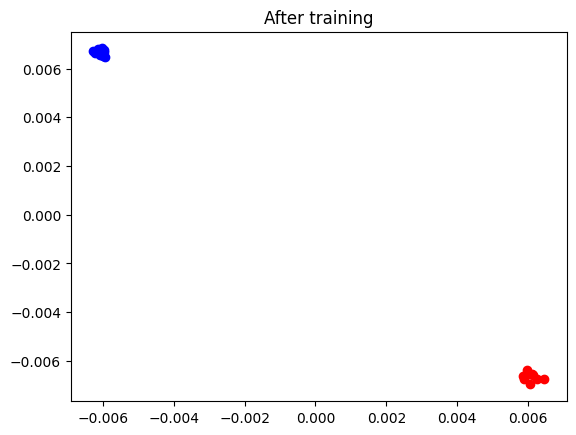

In [121]:
mean1=np.ones(10)
mean2=np.ones(10)*10
cov=np.eye(10)*0.01

x1=np.random.multivariate_normal(mean1,cov,10)
x2=np.random.multivariate_normal(mean2,cov,10)

X= np.vstack([x1, x2])

dim_embedded = 2
T = 50
eta = 0.5
alpha = 0.2

sigma = 1

def compute_affinities(X, sigma):
    n = X.shape[0]
    p = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
          diff=X[i]-X[j]
          z=np.exp(-np.dot(diff,diff)/(2*sigma**2))

          a=0
          for k in range(n):
            diff=X[i]-X[k]
            a=np.exp(-np.dot(diff,diff)/(2*sigma**2))+a

          pji=z/a

          diff=X[j]-X[i]
          z=np.exp(-np.dot(diff,diff)/(2*sigma**2))

          a=0
          for k in range(n):
            diff=X[j]-X[k]
            a=np.exp(-np.dot(diff,diff)/(2*sigma**2))+a

          pij=z/a

          p[i,j]=(pij+pji)/(2*n)

    return p

P = compute_affinities(X, sigma)

Y = np.random.normal(0, 1e-4, (20, dim_embedded))

x,y=Y.T
plt.scatter(x[:10],y[:10],color="red")
plt.scatter(x[10:],y[10:],color="blue")
plt.title("Before training")
plt.show()

Ypre=np.zeros_like(Y)

for t in range(T):

    Q = np.zeros((20, 20))

    for i in range(20):
        for j in range(20):
          diff=Y[i]-Y[j]
          z=1/(1+np.dot(diff,diff))


          w=0
          for k in range(20):
            for l in range(20):
              diff=Y[k]-Y[l]

              w=1/(1+np.dot(diff,diff))+w

          Q[i,j]=z/w

    if(t==0):
      Q1=Q
    if(t==49):
      Q2=Q

    gradient = np.zeros_like(Y)
    for i in range(20):
        for j in range(20):
          gradient[i] += 4 * (P[i, j] - Q[i, j]) * (Y[i] - Y[j]) / (1 + np.dot(Y[i] - Y[j], Y[i] - Y[j]))


    Y1 = Y - eta * gradient + alpha * (Y - Ypre)
    Ypre=Y
    Y=Y1

x,y=Y.T
plt.scatter(x[:10],y[:10],color="red")
plt.scatter(x[10:],y[10:],color="blue")
plt.title("After training")
plt.show()



From graph we can observe that after applying tsne algorithm on data points ,the data points of same similarites come close and data points that have differnt similarities apart from each other.

In [123]:
def KL_divergence2d(px,py):
  KL=0
  for i in range(len(px)):
    for j in range(len(px)):
      if(py[i][j]==0 or px[i][j]==0):
        continue
      KL=KL+px[i][j]*np.log2(px[i][j]/py[i][j])

  return KL

print("KL divergence before :",KL_divergence2d(P,Q1))
print("KL divergence after :",KL_divergence2d(P,Q2))


KL divergence before : 1.001689687274302
KL divergence after : 1.0015036510196955


The KL divergence before is greater than the KL divergence after.
The algorithm reduce the the KL divergence.

(c)

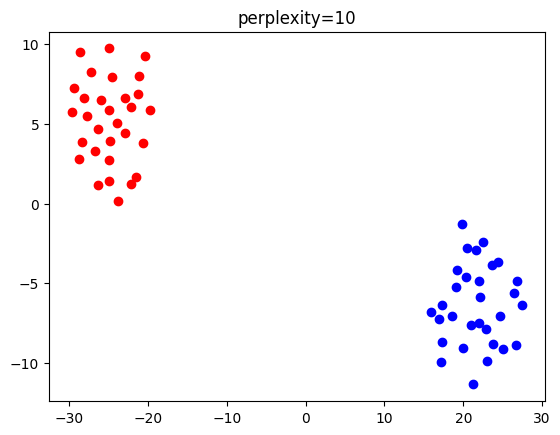

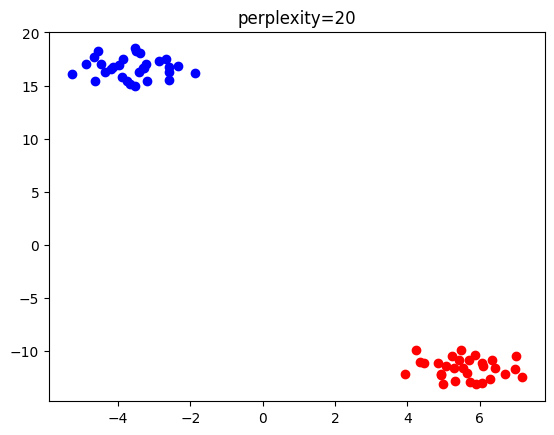

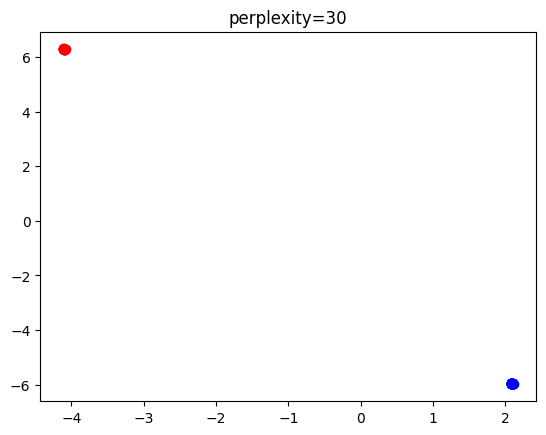

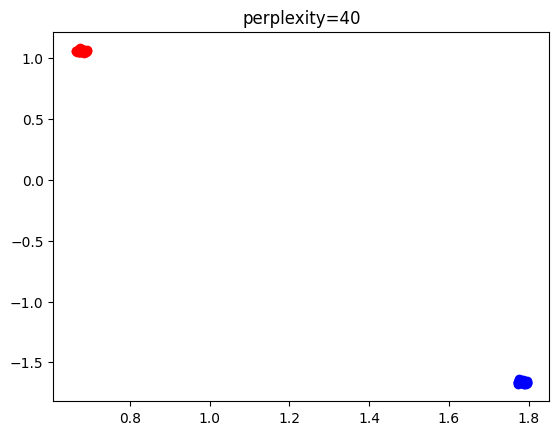

In [124]:
from sklearn.manifold import TSNE

mean1=np.ones(10)
mean2=np.ones(10)*10
cov=np.eye(10)*0.01

x1=np.random.multivariate_normal(mean1,cov,30)
x2=np.random.multivariate_normal(mean2,cov,30)

X= np.vstack([x1, x2])

perplexities = [10, 20, 30, 40]

for i in range(len(perplexities)):
  tsne=TSNE(n_components=2, perplexity=perplexities[i], random_state=42)
  X_embedded = tsne.fit_transform(X)

  x,y=X_embedded.T
  plt.scatter(x[:30],y[:30],color='red')
  plt.scatter(x[30:],y[30:],color='blue')
  plt.title(f"perplexity={perplexities[i]}")
  plt.show()


from increasing the perplexity the data points of same similarities come closer and closer and data points of different similarities goes away.